# Análise de concentração de fornecedores nas compras públicas de microcomputadores.

**Pergunta de pesquisa:**

As compras públicas de micrococompmputadores estão concentradas em poucos fornecedores?

- Temos vários fornecedores vendendo microcomputadores para o governo. Queremos saber se o valor das compras está distribuído entre muitos fornecedores ou se uma parcela grande está concentrada em poucos deles.

- Iremos analisar a distribuição dos registros de compras públicas de microcomputadores entre os fornecedores, identificando a concentração dos valores registrados e a participação dos principais fornecedores.

**Hipótese inicial**: espera-se que uma parcela relevante do valor dos registros analisados esteja concentrada em um grupo reduzido de fornecedores.

**Justificativa**:  Microcomputadores são utilizados por órgãos públicos em atividades administrativas, educacionais e operacionais. A análise da distribuição dos fornecedores ajuda a verificar se os registros de preços estão concentrados em poucos fornecedores ou distribuídos entre diferentes fornecedores, contribuindo para compreender o perfil das compras públicas desse tipo de material.

### **Fonte dos dados**

API de Dados Abertos do Compras.gov.br - módulo de Pesquisa de Preços.

### **Objeto analisado**

PDM 06484 - Microcomputador.

In [27]:
# importação das bibliotecas

import requests
import pandas as pd
import time

# 1. Configuração da API

Nesta etapa vamos definir o endereço da API, o endpoint utilizado e os parâmetros.

A consulta será realizada utilizando o código PDM do material analisado.

In [28]:
BASE_URL = "https://dadosabertos.compras.gov.br"
ENDPOINT = "/modulo-pesquisa-preco/1_consultarMaterial"
url = BASE_URL + ENDPOINT
print(url)

https://dadosabertos.compras.gov.br/modulo-pesquisa-preco/1_consultarMaterial


In [32]:
params = {
    "pagina": 1,
    "tamanhoPagina": 500,
    "tipo": "codigoPdm",
    "codigo": "06484",
    "dataResultado": True
}

# 2. Consulta piloto

Antes da coleta principal, foi realizada uma consulta piloto para verificar:

- disponibilidade do endpoint;
- funcionamento da requisição;
- quantidade de registros retornados;
- estrutura dos dados;
- presença das variáveis necessárias;
- possibilidade de identificar fornecedores;
- possibilidade de identificar compras, preços e quantidades.

In [33]:
resposta = requests.get(url, params=params, timeout=60)

print("Status HTTP:", resposta.status_code)
print("URL gerada:", resposta.url)

if resposta.status_code == 200:
    dados_json = resposta.json()
    print("Total de registros no JSON:", dados_json.get("totalRegistros", 0))
else:
    print("erro na resposta do servidor:", resposta.status_code)
    dados_json = {}

Status HTTP: 200
URL gerada: https://dadosabertos.compras.gov.br/modulo-pesquisa-preco/1_consultarMaterial?pagina=1&tamanhoPagina=500&tipo=codigoPdm&codigo=06484&dataResultado=True
Total de registros no JSON: 700


In [34]:
registros_piloto = dados_json.get("resultado", [])

df_piloto = pd.json_normalize(registros_piloto)

print("Registros retornados na página:", len(df_piloto))
print("Número de colunas:", len(df_piloto.columns))

Registros retornados na página: 500
Número de colunas: 41


In [35]:
print("Colunas disponíveis:")
for coluna in df_piloto.columns:
    print("-", coluna)

Colunas disponíveis:
- idCompra
- dataCompra
- forma
- modalidade
- dataHoraAtualizacaoCompra
- idItemCompra
- numeroItemCompra
- niFornecedor
- codigoItemCatalogo
- quantidade
- precoUnitario
- descricaoItem
- siglaUnidadeFornecimento
- nomeUnidadeFornecimento
- capacidadeUnidadeFornecimento
- siglaUnidadeMedida
- nomeUnidadeMedida
- criterioJulgamento
- percentualMaiorDesconto
- nomeFornecedor
- marca
- dataResultado
- dataHoraAtualizacaoItem
- codigoUasg
- nomeUasg
- codigoOrgao
- nomeOrgao
- estado
- codigoMunicipio
- municipio
- poder
- esfera
- dataHoraAtualizacaoUasg
- codigoClasse
- nomeClasse
- idCompraItem
- objetoCompra
- descricaoDetalhadaItem
- dataAtualizacaoFato
- codigoPdm
- nomePdm


In [39]:
colunas_interesse = [
    "idCompra",
    "dataCompra",
    "numeroItemCompra",
    "niFornecedor",
    "quantidade",
    "precoUnitario",
    "descricaoItem",
    "nomeFornecedor",
    "marca",
    "estado",
    "municipio",
    "objetoCompra",
    "nomeOrgao",
    "nomePdm",
    "codigoItemCatalogo"
]

colunas_existentes = [
    coluna
    for coluna in colunas_interesse
    if coluna in df_piloto.columns
]

print("variáveis necessarias encontradas:")
print(colunas_existentes)

variáveis necessarias encontradas:
['idCompra', 'dataCompra', 'numeroItemCompra', 'niFornecedor', 'quantidade', 'precoUnitario', 'descricaoItem', 'nomeFornecedor', 'marca', 'estado', 'municipio', 'objetoCompra', 'nomeOrgao', 'nomePdm', 'codigoItemCatalogo']


# 3. Tratamento e limpeza dos dados

Antes da análise, será realizada uma avaliação dos dados dessa base.

Serão verificados:

- tipos das variáveis;
- valores ausentes;
- registros duplicados;
- consistência das datas;
- consistência dos valores e quantidades;
- identificação de possíveis registros que não devem participar da análise.

In [40]:

print("Linhas e colunas:", df_coleta.shape)

print("\nTipos das variáveis:")
print(df_coleta.dtypes)

print("\nValores ausentes:")
print(df_coleta.isna().sum().sort_values(ascending=False))


Linhas e colunas: (500, 41)

Tipos das variáveis:
idCompra                           int64
dataCompra                           str
forma                                str
modalidade                         int64
dataHoraAtualizacaoCompra            str
idItemCompra                       int64
numeroItemCompra                   int64
niFornecedor                         str
codigoItemCatalogo                 int64
quantidade                       float64
precoUnitario                    float64
descricaoItem                        str
siglaUnidadeFornecimento             str
nomeUnidadeFornecimento              str
capacidadeUnidadeFornecimento    float64
siglaUnidadeMedida                object
nomeUnidadeMedida                 object
criterioJulgamento                   str
percentualMaiorDesconto          float64
nomeFornecedor                       str
marca                                str
dataResultado                        str
dataHoraAtualizacaoItem              str
codigoU

In [22]:
print("Registros duplicados:", df_coleta.duplicated().sum())

Registros duplicados: 0


In [37]:
print("Fornecedores únicos:", df_coleta["niFornecedor"].nunique())
print("Compras únicas:", df_coleta["idCompra"].nunique())
print("Estados:", df_coleta["estado"].nunique())
print("Municípios:", df_coleta["municipio"].nunique())

Fornecedores únicos: 268
Compras únicas: 351
Estados: 27
Municípios: 155


In [24]:
print("Registros:", len(df_coleta))
print("Duplicados:", df_coleta.duplicated().sum())
print("Valores ausentes em preço:", df_coleta["precoUnitario"].isna().sum())
print("Valores ausentes em quantidade:", df_coleta["quantidade"].isna().sum())
print("Preços <= 0:", (df_coleta["precoUnitario"] <= 0).sum())
print("Quantidades <= 0:", (df_coleta["quantidade"] <= 0).sum())

Registros: 500
Duplicados: 0
Valores ausentes em preço: 0
Valores ausentes em quantidade: 0
Preços <= 0: 0
Quantidades <= 0: 0



Antes da análise, foi realizada uma verificação da qualidade e consistência da base de dados.

Foram analisados:

- quantidade de registros;
- registros duplicados;
- valores ausentes nas variáveis de preço e quantidade;
- valores menores ou iguais a zero nas variáveis de preço e quantidade.

### Resultado da verificação

A base possui **700 registros** e não foram identificados registros duplicados.

As variáveis `precoUnitario` e `quantidade` não apresentam valores ausentes ou valores menores ou iguais a zero, dessa forma, esses registros foram mantidos para a análise.

Algumas variáveis relacionadas às unidades de medida apresentam valores ausentes. Como essas informações não são necessárias para responder à pergunta de pesquisa, elas não serão utilizadas na análise.

# 4. Preparação dos dados

Será criada uma variável de valor total, calculada pela multiplicação da quantidade pelo preço unitário. Também serão organizadas as informações de data para permitir análises ao longo do período.

In [26]:
df_analise = df_coleta.copy()

# Converter a data
df_analise["dataCompra"] = pd.to_datetime(
    df_analise["dataCompra"],
    errors="coerce"
)

# Criar ano e mês
df_analise["ano"] = df_analise["dataCompra"].dt.year

df_analise["mes"] = df_analise["dataCompra"].dt.month

df_analise["ano_mes"] = (
    df_analise["dataCompra"]
    .dt.to_period("M")
    .astype(str)
)

# Calcular o valor total de cada registro
df_analise["valor_total"] = (
    df_analise["quantidade"] *
    df_analise["precoUnitario"]
)

print("Dimensão da base:", df_analise.shape)

Dimensão da base: (500, 45)


In [ ]:
def coletar_todas_paginas(endpoint, parametros):

    todos = []
    pagina = 1

    while True:

        params_pagina = parametros.copy()
        params_pagina["pagina"] = pagina

        resposta = requests.get(
            BASE_URL + endpoint,
            params=params_pagina,
            timeout=60
        )

        resposta.raise_for_status()

        dados = resposta.json()
        registros = extrair_registros(dados)

        print(f"Página {pagina}: {len(registros)} registros")

        if len(registros) == 0:
            break

        todos.extend(registros)

        pagina += 1

        time.sleep(0.2)

    return pd.json_normalize(todos)

In [ ]:
df_coleta = coletar_todas_paginas(
    ENDPOINT,
    params
)

print("Dimensão final:", df_coleta.shape)

Página 1: 500 registros
Página 2: 200 registros
Página 3: 0 registros
Dimensão final: (700, 41)


In [ ]:
print("Total coletado:", len(df_coleta))

Total coletado: 700


In [ ]:
print("Fornecedores únicos:", df_coleta["niFornecedor"].nunique())
print("Compras únicas:", df_coleta["idCompra"].nunique())
print("Estados:", df_coleta["estado"].nunique())
print("Municípios:", df_coleta["municipio"].nunique())

Fornecedores únicos: 361
Compras únicas: 475
Estados: 27
Municípios: 207


In [ ]:
print(
    "Período:",
    df_coleta["dataCompra"].min(),
    "até",
    df_coleta["dataCompra"].max()
)

Período: 2021-12-02 até 2026-09-14


In [ ]:
colunas_interesse = [
    "idCompra",
    "dataCompra",
    "dataHoraAtualizacaoCompra",
    "numeroItemCompra",
    "niFornecedor",
    "quantidade",
    "precoUnitario",
    "descricaoItem",
    "percentualMaiorDesconto",
    "nomeFornecedor",
    "marca",
    "estado",
    "municipio",
    "objetoCompra",
    "nomeOrgao",
    "nomePdm"
]

colunas_existentes = [c for c in colunas_interesse if c in df.columns]

print("Colunas encontradas:")
print(colunas_existentes)

df[colunas_existentes].head() if colunas_existentes else df.head()

Colunas encontradas:
['idCompra', 'dataCompra', 'dataHoraAtualizacaoCompra', 'numeroItemCompra', 'niFornecedor', 'quantidade', 'precoUnitario', 'descricaoItem', 'percentualMaiorDesconto', 'nomeFornecedor', 'marca', 'estado', 'municipio', 'objetoCompra', 'nomeOrgao', 'nomePdm']


,idCompra,dataCompra,dataHoraAtualizacaoCompra,numeroItemCompra,niFornecedor,quantidade,precoUnitario,descricaoItem,percentualMaiorDesconto,nomeFornecedor,marca,estado,municipio,objetoCompra,nomeOrgao,nomePdm
0,98055105900042025,2026-09-14,2026-09-15T01:10:02.645508,3,04470529000120,186.0,5629.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,PEG PAG LTDA,ALL IN ONE,PA,SÃO MIGUEL DO GUAMÁ,Objeto: Pregão Eletrônico - Registro de preço...,PREFEITURA MUNICIPAL SÃO MIGUEL DO GUAMÁ - PA,MICROCOMPUTADOR ALL IN ONE
1,98055105900042025,2026-09-14,2026-09-15T01:10:02.645508,4,10668134000139,104.0,6850.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,R L BASTOS INFORMATICA LTDA,"I5 7º GERAÇÃO, 4 GB",PA,SÃO MIGUEL DO GUAMÁ,Objeto: Pregão Eletrônico - Registro de preço...,PREFEITURA MUNICIPAL SÃO MIGUEL DO GUAMÁ - PA,MICROCOMPUTADOR ALL IN ONE
2,98863105000042026,2026-07-01,2026-09-05T02:22:57.601276,2,26947090000116,13.0,4899.85,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,ROSEMARA DOS SANTOS,PROPRIA,RS,DONA FRANCISCA,Aquisição de Equipamentos de Informática para ...,PREFEITURA MUNICIPAL DE DONA FRANCISCA - RS,MICROCOMPUTADOR ALL IN ONE
3,98774505900262026,2026-08-27,2026-08-28T07:46:08.385209,3,57601436000153,5.0,4722.70,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,MAMUTH TECNOLOGIA DISTRIBUIDORA LTDA,AXPRO/BINÁRIO,PR,PARANAGUÁ,Objeto: Pregão Eletrônico - Aquisição de Equi...,PREFEITURA DE PARANAGUÁ - PR,MICROCOMPUTADOR ALL IN ONE
4,98910705900072026,2026-08-25,2026-08-26T01:10:02.688182,2,64343195000155,24.0,4980.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,64.343.195 GIOVANNA DO VALE LOPES ALVES SALES,microcomputador all,MS,MARACAJU,Objeto: Pregão Eletrônico - Aquisição de mate...,PREFEITURA MUNICIPAL DE MARACAJU - MS,MICROCOMPUTADOR ALL IN ONE


In [ ]:
def extrair_registros(json_resposta):
    if isinstance(json_resposta, list):
        return json_resposta

    if not isinstance(json_resposta, dict):
        return []

    for chave in ["resultado", "resultados", "data", "content"]:
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave]

    return []



In [ ]:
colunas_interesse = [
    "idCompra",
    "dataCompra",
    "dataHoraAtualizacaoCompra",
    "numeroItemCompra",
    "niFornecedor",
    "quantidade",
    "precoUnitario",
    "descricaoItem",
    "percentualMaiorDesconto",
    "nomeFornecedor",
    "marca",
    "estado",
    "municipio",
    "objetoCompra",
    "nomeOrgao",
    "nomePdm"
]

colunas_existentes = [c for c in colunas_interesse if c in df.columns]

print("Colunas encontradas:")
print(colunas_existentes)

df[colunas_existentes].head() if colunas_existentes else df.head()


Colunas encontradas:
['idCompra', 'dataCompra', 'dataHoraAtualizacaoCompra', 'numeroItemCompra', 'niFornecedor', 'quantidade', 'precoUnitario', 'descricaoItem', 'percentualMaiorDesconto', 'nomeFornecedor', 'marca', 'estado', 'municipio', 'objetoCompra', 'nomeOrgao', 'nomePdm']


,idCompra,dataCompra,dataHoraAtualizacaoCompra,numeroItemCompra,niFornecedor,quantidade,precoUnitario,descricaoItem,percentualMaiorDesconto,nomeFornecedor,marca,estado,municipio,objetoCompra,nomeOrgao,nomePdm
0,98055105900042025,2026-09-14,2026-09-15T01:10:02.645508,3,04470529000120,186.0,5629.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,PEG PAG LTDA,ALL IN ONE,PA,SÃO MIGUEL DO GUAMÁ,Objeto: Pregão Eletrônico - Registro de preço...,PREFEITURA MUNICIPAL SÃO MIGUEL DO GUAMÁ - PA,MICROCOMPUTADOR ALL IN ONE
1,98055105900042025,2026-09-14,2026-09-15T01:10:02.645508,4,10668134000139,104.0,6850.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,R L BASTOS INFORMATICA LTDA,"I5 7º GERAÇÃO, 4 GB",PA,SÃO MIGUEL DO GUAMÁ,Objeto: Pregão Eletrônico - Registro de preço...,PREFEITURA MUNICIPAL SÃO MIGUEL DO GUAMÁ - PA,MICROCOMPUTADOR ALL IN ONE
2,98863105000042026,2026-07-01,2026-09-05T02:22:57.601276,2,26947090000116,13.0,4899.85,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,ROSEMARA DOS SANTOS,PROPRIA,RS,DONA FRANCISCA,Aquisição de Equipamentos de Informática para ...,PREFEITURA MUNICIPAL DE DONA FRANCISCA - RS,MICROCOMPUTADOR ALL IN ONE
3,98774505900262026,2026-08-27,2026-08-28T07:46:08.385209,3,57601436000153,5.0,4722.70,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,MAMUTH TECNOLOGIA DISTRIBUIDORA LTDA,AXPRO/BINÁRIO,PR,PARANAGUÁ,Objeto: Pregão Eletrônico - Aquisição de Equi...,PREFEITURA DE PARANAGUÁ - PR,MICROCOMPUTADOR ALL IN ONE
4,98910705900072026,2026-08-25,2026-08-26T01:10:02.688182,2,64343195000155,24.0,4980.00,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",0.0,64.343.195 GIOVANNA DO VALE LOPES ALVES SALES,microcomputador all,MS,MARACAJU,Objeto: Pregão Eletrônico - Aquisição de mate...,PREFEITURA MUNICIPAL DE MARACAJU - MS,MICROCOMPUTADOR ALL IN ONE


In [ ]:
def coletar_paginas(endpoint, parametros, numero_paginas=3):
    todos = []

    for pagina in range(1, numero_paginas + 1):

        params_pagina = parametros.copy()
        params_pagina["pagina"] = pagina

        resposta = requests.get(
            BASE_URL + endpoint,
            params=params_pagina,
            timeout=60
        )

        resposta.raise_for_status()

        registros = extrair_registros(resposta.json())

        print(f"Página {pagina}: {len(registros)} registros")

        if len(registros) == 0:
            break

        todos.extend(registros)

    return pd.json_normalize(todos)

In [ ]:
print("Linhas duplicadas completas:", df_coleta.duplicated().sum())

if "niFornecedor" in df_coleta.columns:
    print("CNPJ duplicados:", df_coleta["niFornecedor"].duplicated().sum())

Linhas duplicadas completas: 0
CNPJ duplicados: 15


In [ ]:
if "niFornecedor" in df_coleta.columns:
    cnpjs_duplicados = df_coleta[
        df_coleta["niFornecedor"].duplicated(keep=False)
    ]["niFornecedor"]

    print("CNPJs duplicados:")
    print(cnpjs_duplicados.dropna())


CNPJs duplicados:
1     58733880000195
7     23539439000192
8     23539439000192
9     46491524000123
10    46491524000123
13    04602789000101
18    46491524000123
19    58733880000195
21    46491524000123
25    27120037000100
26    27120037000100
29    46491524000123
30    58733880000195
34    46491524000123
36    04602789000101
37    04602789000101
43    46491524000123
44    46491524000123
45    46491524000123
54    25075527000106
56    25075527000106
Name: niFornecedor, dtype: object


In [ ]:
cnpjs_duplicados = df_coleta[
    df_coleta["niFornecedor"].duplicated(keep=False)
]

df_duplicados = cnpjs_duplicados.sort_values("niFornecedor")

print(df_duplicados.to_string(index=False))

         idCompra dataCompra forma  modalidade  dataHoraAtualizacaoCompra  idItemCompra  numeroItemCompra   niFornecedor  codigoItemCatalogo  quantidade  precoUnitario                                                                                                                                                                                                                                                                                                                                            descricaoItem siglaUnidadeFornecimento nomeUnidadeFornecimento  capacidadeUnidadeFornecimento siglaUnidadeMedida nomeUnidadeMedida criterioJulgamento  percentualMaiorDesconto                               nomeFornecedor                marca dataResultado    dataHoraAtualizacaoItem codigoUasg                                      nomeUasg  codigoOrgao                                nomeOrgao estado  codigoMunicipio      municipio poder esfera dataHoraAtualizacaoUasg  codigoClasse   nomeClasse      

In [ ]:
# 10 maiores compras individuais
maiores_compras = (
    df_coleta
    .sort_values("precoUnitario", ascending=False)
    .head(10)
)

print(maiores_compras.to_string(index=False))

         idCompra dataCompra forma  modalidade  dataHoraAtualizacaoCompra  idItemCompra  numeroItemCompra   niFornecedor  codigoItemCatalogo  quantidade  precoUnitario                                                                                                                                                                                                                                                                                                                                            descricaoItem siglaUnidadeFornecimento nomeUnidadeFornecimento  capacidadeUnidadeFornecimento siglaUnidadeMedida nomeUnidadeMedida criterioJulgamento  percentualMaiorDesconto                                                 nomeFornecedor                marca dataResultado    dataHoraAtualizacaoItem codigoUasg                                      nomeUasg  codigoOrgao                                   nomeOrgao estado  codigoMunicipio           municipio poder esfera dataHoraAtualizacaoUasg  codig

In [ ]:
df_coleta["valor_total"] = (
    df_coleta["precoUnitario"] * df_coleta["quantidade"]
)

print(
    df_coleta[
        ["niFornecedor", "precoUnitario", "quantidade", "valor_total"]
    ].sort_values("valor_total", ascending=False)
    .to_string(index=False)
)

  niFornecedor  precoUnitario  quantidade  valor_total
04602789000101        5375.00      1000.0   5375000.00
05778325000547        5980.00       231.0   1381380.00
14457456000190        8837.51       100.0    883751.00
52593051000178       12854.00        60.0    771240.00
30898800000132      184472.00         2.0    368944.00
04602789000101        5399.99        68.0    367199.32
58733880000195       18000.00        20.0    360000.00
04602789000101        5580.00        61.0    340380.00
04958321000154        8400.00        40.0    336000.00
45783227000199        4539.00        50.0    226950.00
52306419000170        8100.00        25.0    202500.00
46491524000123        9580.00        20.0    191600.00
39251946000166        7590.00        23.0    174570.00
33629177000100        5339.40        30.0    160182.00
47168542000131        6928.00        23.0    159344.00
42923049000247        5690.00        22.0    125180.00
48411373000181        5850.00        20.0    117000.00
4649152400

In [ ]:
analise = df_coleta.sort_values(
    ["precoUnitario", "quantidade"],
    ascending=[False, False]
)

print(
    analise[
        ["niFornecedor", "precoUnitario", "quantidade", "valor_total"]
    ].head(20).to_string(index=False)
)

  niFornecedor  precoUnitario  quantidade  valor_total
30898800000132      184472.00         2.0    368944.00
34185269000101       19450.00         1.0     19450.00
29252540000144       18790.00         2.0     37580.00
58733880000195       18695.10         1.0     18695.10
58733880000195       18000.00        20.0    360000.00
50614681000156       15830.00         2.0     31660.00
46491524000123       15400.00         2.0     30800.00
57163510000105       13841.40         1.0     13841.40
45909091000110       13310.00         1.0     13310.00
52593051000178       12854.00        60.0    771240.00
46491524000123        9580.00        20.0    191600.00
14457456000190        8837.51       100.0    883751.00
49800668000102        8421.00         2.0     16842.00
04958321000154        8400.00        40.0    336000.00
52306419000170        8100.00        25.0    202500.00
46491524000123        8000.00         1.0      8000.00
23539439000192        7990.00         1.0      7990.00
4649152400

In [ ]:
cnpj = "28763325000145"

resultado = df_coleta[
    df_coleta["niFornecedor"].astype(str) == cnpj
]

print(resultado.to_string(index=False))

Empty DataFrame
Columns: [idCompra, dataCompra, forma, modalidade, dataHoraAtualizacaoCompra, idItemCompra, numeroItemCompra, niFornecedor, codigoItemCatalogo, quantidade, precoUnitario, descricaoItem, siglaUnidadeFornecimento, nomeUnidadeFornecimento, capacidadeUnidadeFornecimento, siglaUnidadeMedida, nomeUnidadeMedida, criterioJulgamento, percentualMaiorDesconto, nomeFornecedor, marca, dataResultado, dataHoraAtualizacaoItem, codigoUasg, nomeUasg, codigoOrgao, nomeOrgao, estado, codigoMunicipio, municipio, poder, esfera, dataHoraAtualizacaoUasg, codigoClasse, nomeClasse, idCompraItem, objetoCompra, descricaoDetalhadaItem, dataAtualizacaoFato, codigoPdm, nomePdm, valor_total]
Index: []


In [ ]:
cnpj = "26994083000175"

fornecedor = df_coleta[
    df_coleta["niFornecedor"].astype(str) == cnpj
]

print("Informações do fornecedor:")
print(fornecedor.to_string(index=False))

print("\nResumo:")
print("Quantidade de compras:", len(fornecedor))
print("Quantidade total de itens:", fornecedor["quantidade"].sum())
print("Valor total comprado:", fornecedor["valor_total"].sum())
print("Maior compra:", fornecedor["valor_total"].max())
print("Valor unitário médio:", fornecedor["precoUnitario"].mean())

Informações do fornecedor:
Empty DataFrame
Columns: [idCompra, dataCompra, forma, modalidade, dataHoraAtualizacaoCompra, idItemCompra, numeroItemCompra, niFornecedor, codigoItemCatalogo, quantidade, precoUnitario, descricaoItem, siglaUnidadeFornecimento, nomeUnidadeFornecimento, capacidadeUnidadeFornecimento, siglaUnidadeMedida, nomeUnidadeMedida, criterioJulgamento, percentualMaiorDesconto, nomeFornecedor, marca, dataResultado, dataHoraAtualizacaoItem, codigoUasg, nomeUasg, codigoOrgao, nomeOrgao, estado, codigoMunicipio, municipio, poder, esfera, dataHoraAtualizacaoUasg, codigoClasse, nomeClasse, idCompraItem, objetoCompra, descricaoDetalhadaItem, dataAtualizacaoFato, codigoPdm, nomePdm, valor_total]
Index: []

Resumo:
Quantidade de compras: 0
Quantidade total de itens: 0.0
Valor total comprado: 0.0
Maior compra: nan
Valor unitário médio: nan


In [ ]:
%pip install matplotlib

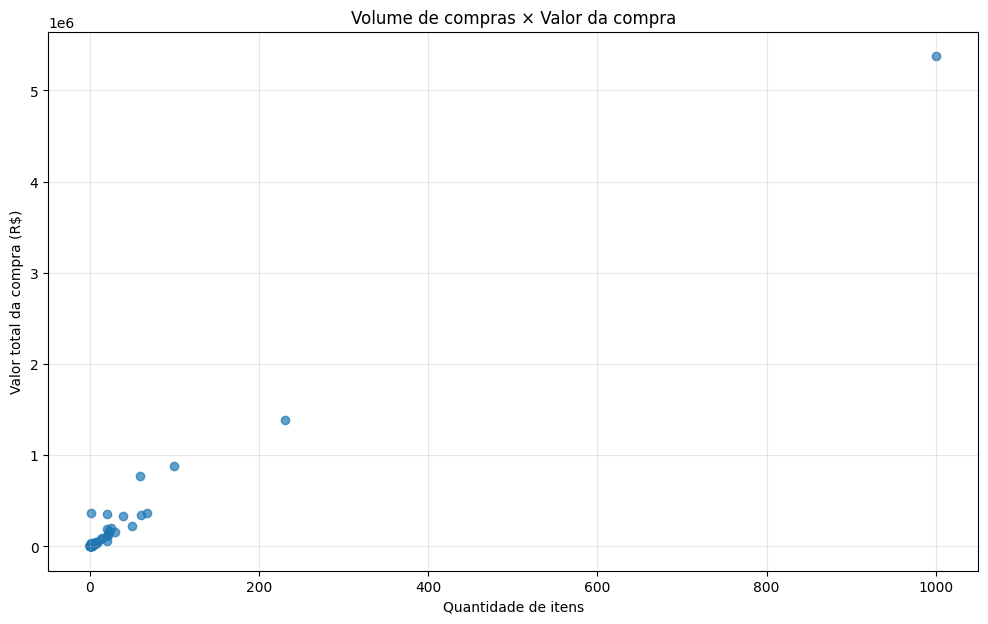

In [ ]:
import matplotlib.pyplot as plt

dados_grafico = (
    df_coleta[["niFornecedor", "quantidade", "valor_total"]]
    .dropna()
    .sort_values("valor_total", ascending=False)

)

plt.figure(figsize=(12, 7))

plt.scatter(
    dados_grafico["quantidade"],
    dados_grafico["valor_total"],
    alpha=0.7
)

plt.xlabel("Quantidade de itens")
plt.ylabel("Valor total da compra (R$)")
plt.title("Volume de compras × Valor da compra")

plt.grid(True, alpha=0.3)
plt.show()

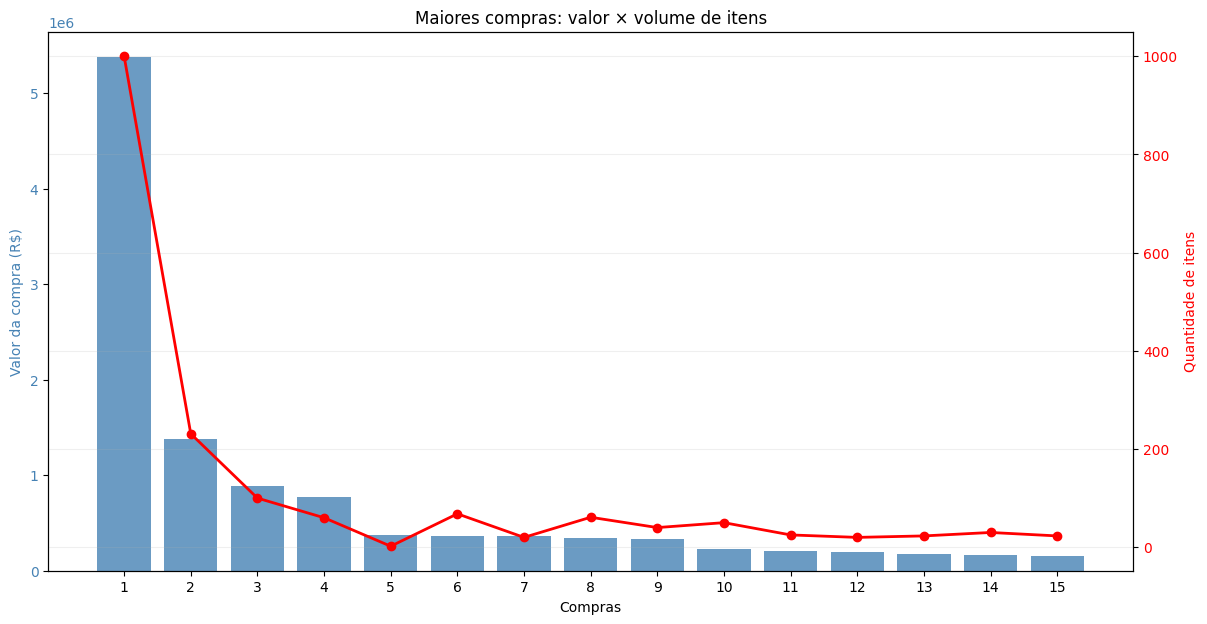

In [ ]:
import matplotlib.pyplot as plt

# Calcula o valor total da compra
df_coleta["valor_total"] = (
    df_coleta["precoUnitario"] * df_coleta["quantidade"]
)

# Seleciona as 15 maiores compras
maiores = (
    df_coleta
    .nlargest(15, "valor_total")
    .copy()
)

# Cria um identificador para cada compra
maiores["compra"] = range(1, len(maiores) + 1)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras = valor da compra
ax1.bar(
    maiores["compra"],
    maiores["valor_total"],
    color="steelblue",
    alpha=0.8
)

ax1.set_xlabel("Compras")
ax1.set_ylabel("Valor da compra (R$)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Linha = quantidade de itens
ax2 = ax1.twinx()

ax2.plot(
    maiores["compra"],
    maiores["quantidade"],
    color="red",
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Quantidade de itens", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Maiores compras: valor × volume de itens")
plt.xticks(maiores["compra"])
plt.grid(axis="y", alpha=0.2)

plt.show()

In [ ]:
df_analise = df_coleta.copy()

In [ ]:
df_analise["dataCompra"] = pd.to_datetime(
    df_analise["dataCompra"],
    errors="coerce"
)

In [ ]:
df_analise["ano"] = df_analise["dataCompra"].dt.year
df_analise["mes"] = df_analise["dataCompra"].dt.month

In [ ]:
df_analise["ano_mes"] = (
    df_analise["dataCompra"]
    .dt.to_period("M")
    .astype(str)
)

In [ ]:
df_analise["valor_total"] = (
    df_analise["quantidade"] *
    df_analise["precoUnitario"]
)

In [ ]:
valores_ausentes = (
    df_analise.isnull()
    .sum()
    .sort_values(ascending=False)
)

valores_ausentes[valores_ausentes > 0]

,0
nomeUnidadeMedida,63
siglaUnidadeMedida,63
poder,2


In [ ]:
df_coleta.duplicated().sum()

np.int64(0)

In [ ]:
print(
    "Linhas completamente duplicadas:",
    df_analise.duplicated().sum()
)

Linhas completamente duplicadas: 0


In [ ]:
print(
    "Fornecedores únicos:",
    df_analise["niFornecedor"].nunique()
)

Fornecedores únicos: 48


In [ ]:
print(
    "Compras únicas:",
    df_analise["idCompra"].nunique()
)

Compras únicas: 57


In [ ]:
print("RESUMO DA BASE")
print("-" * 30)

print("Registros:", len(df_analise))
print("Compras únicas:", df_analise["idCompra"].nunique())
print("Fornecedores:", df_analise["niFornecedor"].nunique())
print("Municípios:", df_analise["municipio"].nunique())
print("Valor total: R$", df_analise["valor_total"].sum())
print("Quantidade total de itens:", df_analise["quantidade"].sum())
print("Preço médio: R$", df_analise["precoUnitario"].mean())
print("Preço mediano: R$", df_analise["precoUnitario"].median())

RESUMO DA BASE
------------------------------
Registros: 63
Compras únicas: 57
Fornecedores: 48
Municípios: 26
Valor total: R$ 12501452.219999999
Quantidade total de itens: 1958.0
Preço médio: R$ 10140.713174603176
Preço mediano: R$ 6190.0


Quais fornecedores movimentaram mais dinheiro?

In [ ]:
gastos_fornecedor = (
    df_analise
    .groupby("nomeFornecedor")
    .agg(
        valor_total=("valor_total", "sum"),
        quantidade=("quantidade", "sum"),
        compras=("idCompra", "nunique")
    )
    .sort_values("valor_total", ascending=False)
)

gastos_fornecedor.head(10)

,valor_total,quantidade,compras
nomeFornecedor,,,
DATEN TECNOLOGIA LTDA,6082579.32,1129.0,3
E.R. SOLUCOES INFORMATICA LTDA,1381380.00,231.0,1
SUPERDATTA TECNOLOGIA LTDA,883751.00,100.0,1
CENTERDATA COMERCIO DE PRODUTOS DE INFORMATICA E SERVICOS LTDA,771240.00,60.0,1
LEC COMERCIO DE PRODUTOS DE INFORMATICA LTDA,407217.52,51.0,8
G C LUZ LTDA,390495.10,23.0,3
ALBATROSS INDUSTRIA AERONAUTICA LTDA,368944.00,2.0,1
HARDLINK INFORMATICA E SISTEMAS LTDA,336000.00,40.0,1
ERRELE LTDA,226950.00,50.0,1


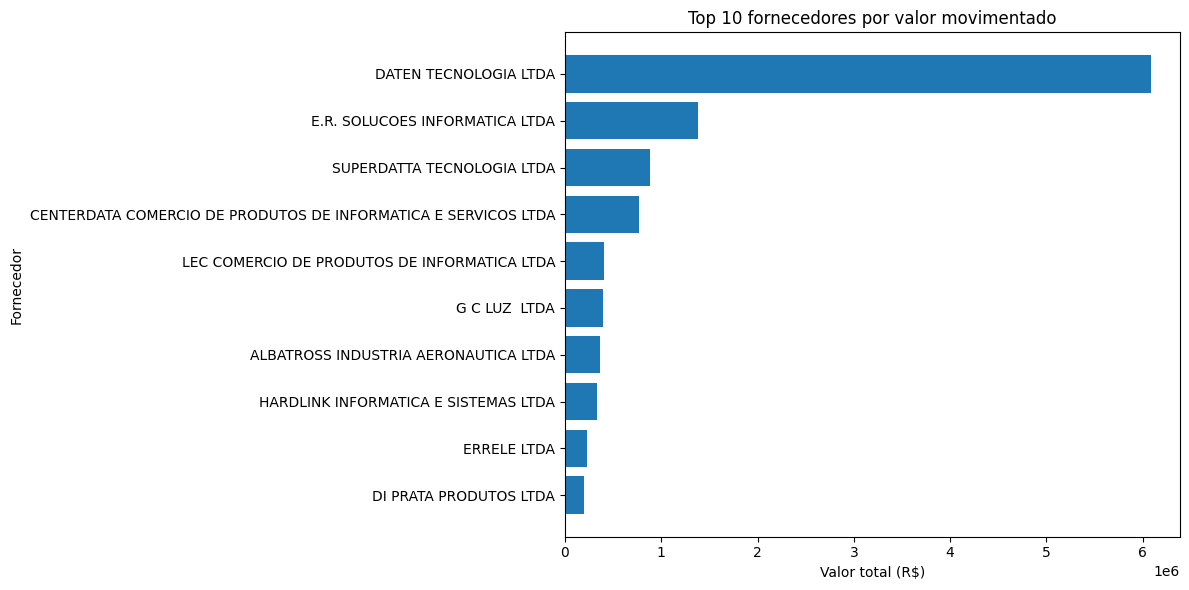

In [ ]:
top_fornecedores = gastos_fornecedor.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_fornecedores.index,
    top_fornecedores["valor_total"]
)

plt.xlabel("Valor total (R$)")
plt.ylabel("Fornecedor")
plt.title("Top 10 fornecedores por valor movimentado")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Quais municípios concentram os maiores gastos?

In [ ]:
gastos_municipio = (
    df_analise
    .groupby("municipio")
    ["valor_total"]
    .sum()
    .sort_values(ascending=False)
)

gastos_municipio.head(10)

,valor_total
municipio,
CAMPINAS,5423452.00
SÃO PAULO,3535215.20
MONTE ALTO,1381380.00
RIBEIRÃO PRETO,792524.00
MARÍLIA,528820.32
SÃO JOSÉ DOS CAMPOS,240791.40
SANTA BÁRBARA D'OESTE,117000.00
ROSANA,78029.28
LARANJAL PAULISTA,62800.00


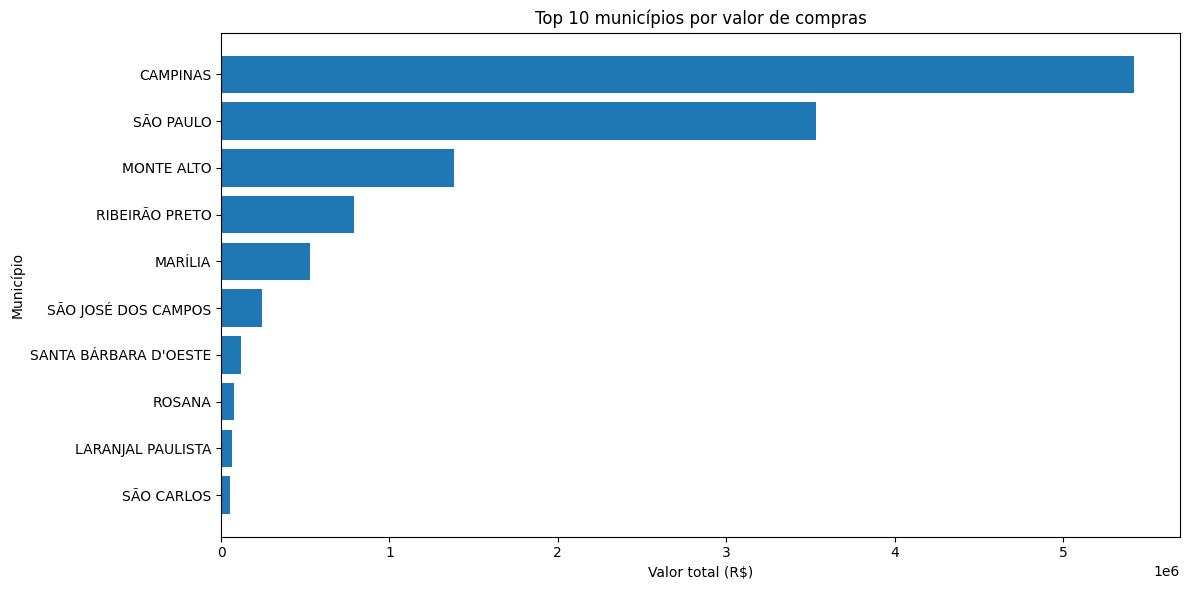

In [ ]:
top_municipios = gastos_municipio.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_municipios.index,
    top_municipios.values
)

plt.xlabel("Valor total (R$)")
plt.ylabel("Município")
plt.title("Top 10 municípios por valor de compras")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Como os gastos variaram ao longo do tempo?

In [ ]:
gastos_mes = (
    df_analise
    .groupby("ano_mes")
    ["valor_total"]
    .sum()
)

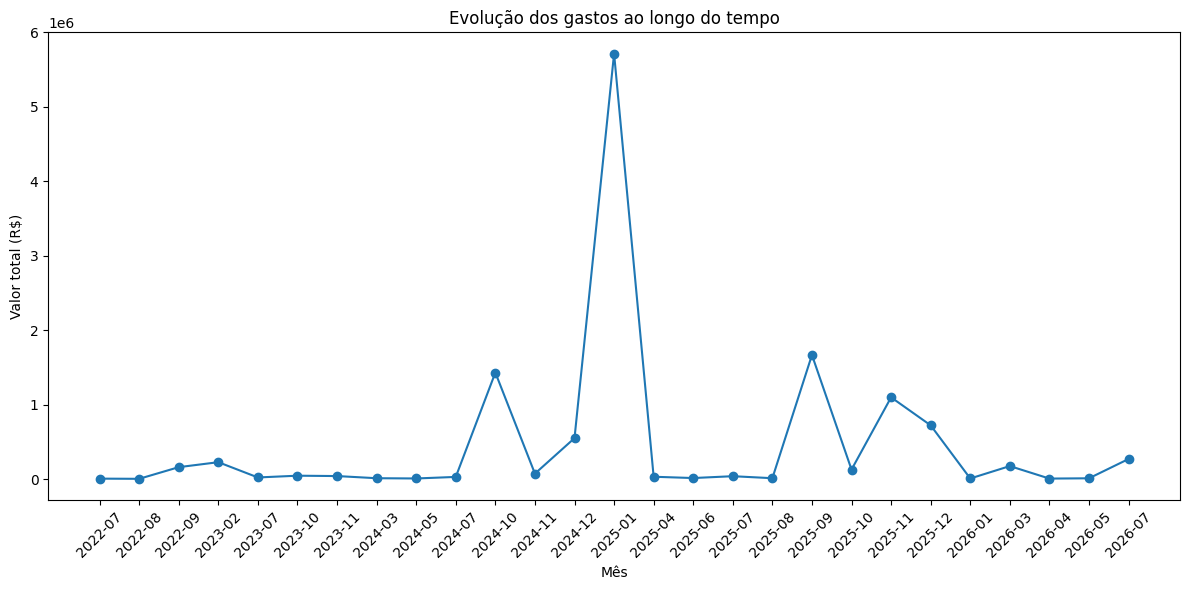

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    gastos_mes.index,
    gastos_mes.values,
    marker="o"
)

plt.xlabel("Mês")
plt.ylabel("Valor total (R$)")
plt.title("Evolução dos gastos ao longo do tempo")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Quais itens tiveram maior valor total?

In [ ]:
maiores_itens = (
    df_analise[
        [
            "descricaoItem",
            "quantidade",
            "precoUnitario",
            "valor_total"
        ]
    ]
    .sort_values("valor_total", ascending=False)
    .head(10)
)

maiores_itens

,descricaoItem,quantidade,precoUnitario,valor_total
37,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",1000.0,5375.00,5375000.00
48,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",231.0,5980.00,1381380.00
27,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",100.0,8837.51,883751.00
28,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",60.0,12854.00,771240.00
38,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",2.0,184472.00,368944.00
13,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",68.0,5399.99,367199.32
19,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",20.0,18000.00,360000.00
36,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",61.0,5580.00,340380.00
17,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",40.0,8400.00,336000.00
59,"MICROCOMPUTADOR ALL IN ONE, TELA: ATÉ 21,5 POL...",50.0,4539.00,226950.00


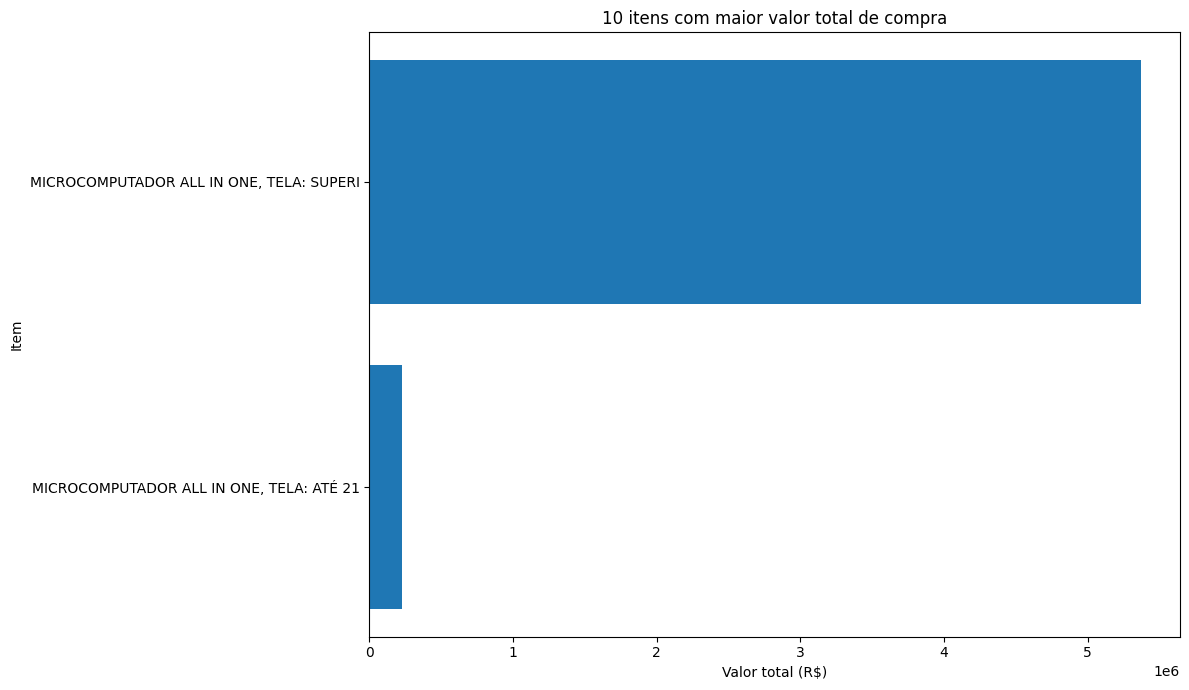

In [ ]:
dados_grafico = maiores_itens.copy()

dados_grafico["descricao"] = (
    dados_grafico["descricaoItem"]
    .str.slice(0, 40)
)

plt.figure(figsize=(12, 7))

plt.barh(
    dados_grafico["descricao"],
    dados_grafico["valor_total"]
)

plt.xlabel("Valor total (R$)")
plt.ylabel("Item")
plt.title("10 itens com maior valor total de compra")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Quantidade comprada × valor total

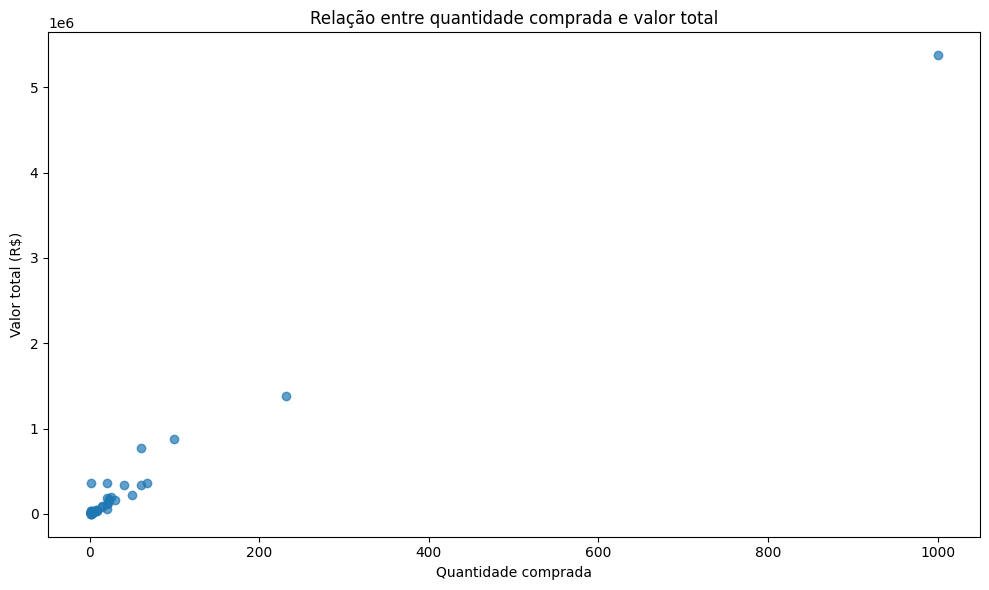

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_analise["quantidade"],
    df_analise["valor_total"],
    alpha=0.7
)

plt.xlabel("Quantidade comprada")
plt.ylabel("Valor total (R$)")
plt.title("Relação entre quantidade comprada e valor total")

plt.tight_layout()
plt.show()

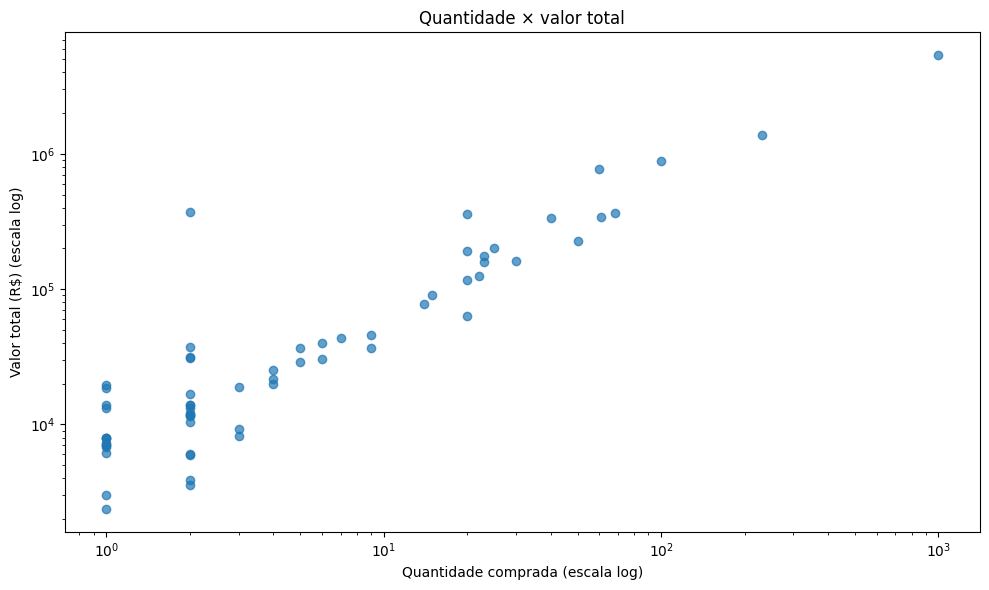

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_analise["quantidade"],
    df_analise["valor_total"],
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Quantidade comprada (escala log)")
plt.ylabel("Valor total (R$) (escala log)")
plt.title("Quantidade × valor total")

plt.tight_layout()
plt.show()

Distribuição dos preços

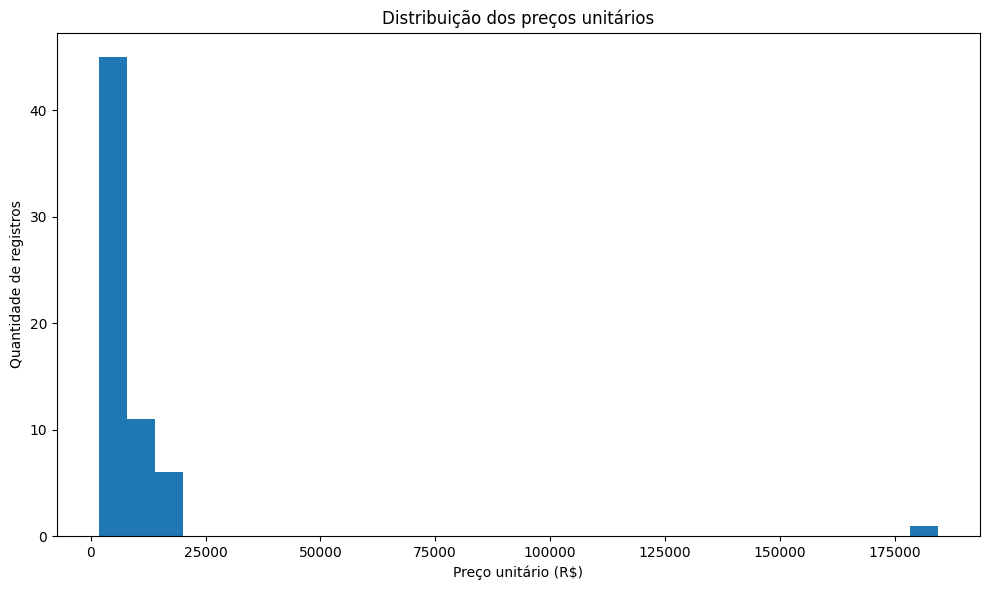

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_analise["precoUnitario"],
    bins=30
)

plt.xlabel("Preço unitário (R$)")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição dos preços unitários")

plt.tight_layout()
plt.show()

Procurar possíveis outliers

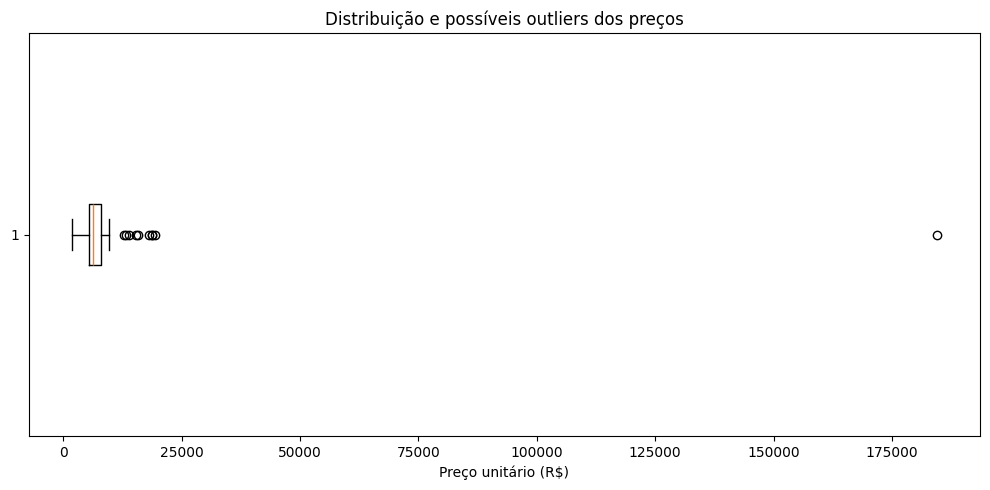

In [ ]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df_analise["precoUnitario"].dropna(),
    vert=False
)

plt.xlabel("Preço unitário (R$)")
plt.title("Distribuição e possíveis outliers dos preços")

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df_analise["precoUnitario"].quantile(0.25)
Q3 = df_analise["precoUnitario"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + (1.5 * IQR)

outliers = df_analise[
    df_analise["precoUnitario"] > limite_superior
]

print("Limite superior:", limite_superior)
print("Quantidade de possíveis outliers:", len(outliers))

Limite superior: 11951.7
Quantidade de possíveis outliers: 10


In [ ]:
outliers[
    [
        "descricaoItem",
        "nomeFornecedor",
        "municipio",
        "precoUnitario",
        "quantidade",
        "valor_total"
    ]
].sort_values(
    "precoUnitario",
    ascending=False
)

,descricaoItem,nomeFornecedor,municipio,precoUnitario,quantidade,valor_total
38,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",ALBATROSS INDUSTRIA AERONAUTICA LTDA,SÃO PAULO,184472.0,2.0,368944.0
35,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",AL 5 COMERCIO DE EQUIPAMENTOS LTDA,SÃO PAULO,19450.0,1.0,19450.0
53,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",CRISTINA LUIZA ALLEGRETTI MARI,SÃO PAULO,18790.0,2.0,37580.0
1,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",G C LUZ LTDA,SÃO PAULO,18695.1,1.0,18695.1
19,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",G C LUZ LTDA,RIBEIRÃO PRETO,18000.0,20.0,360000.0
32,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",50.614.681 JHONATAN RAFAEL DOS SANTOS,PIRACICABA,15830.0,2.0,31660.0
21,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",LEC COMERCIO DE PRODUTOS DE INFORMATICA LTDA,RIBEIRÃO PRETO,15400.0,2.0,30800.0
41,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",57.163.510 LUCIANA FARIA SAINT MARTIN,SÃO JOSÉ DOS CAMPOS,13841.4,1.0,13841.4
16,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",GRS COMERCIO LTDA,ILHA SOLTEIRA,13310.0,1.0,13310.0
28,"MICROCOMPUTADOR ALL IN ONE, TELA: SUPERIOR A 2...",CENTERDATA COMERCIO DE PRODUTOS DE INFORMATICA...,SÃO PAULO,12854.0,60.0,771240.0


Diferenças de preço do mesmo produto

In [ ]:
comparacao_precos = (
    df_analise
    .groupby("codigoItemCatalogo")
    .agg(
        preco_minimo=("precoUnitario", "min"),
        preco_maximo=("precoUnitario", "max"),
        preco_medio=("precoUnitario", "mean"),
        fornecedores=("niFornecedor", "nunique")
    )
)

comparacao_precos["diferenca_preco"] = (
    comparacao_precos["preco_maximo"]
    - comparacao_precos["preco_minimo"]
)

comparacao_precos = (
    comparacao_precos
    .sort_values("diferenca_preco", ascending=False)
)

comparacao_precos.head(10)

,preco_minimo,preco_maximo,preco_medio,fornecedores,diferenca_preco
codigoItemCatalogo,,,,,
481514,1956.99,184472.0,13148.135152,25,182515.01
481548,2975.00,18790.0,7767.923500,17,15815.00
480498,3000.00,7590.0,5043.000000,3,4590.00
480492,5000.00,6100.0,5550.000000,2,1100.00
451802,1785.00,2355.0,2070.000000,2,570.00
451798,7000.00,7000.0,7000.000000,1,0.00
480491,6269.00,6269.0,6269.000000,1,0.00
481547,5980.00,5980.0,5980.000000,1,0.00


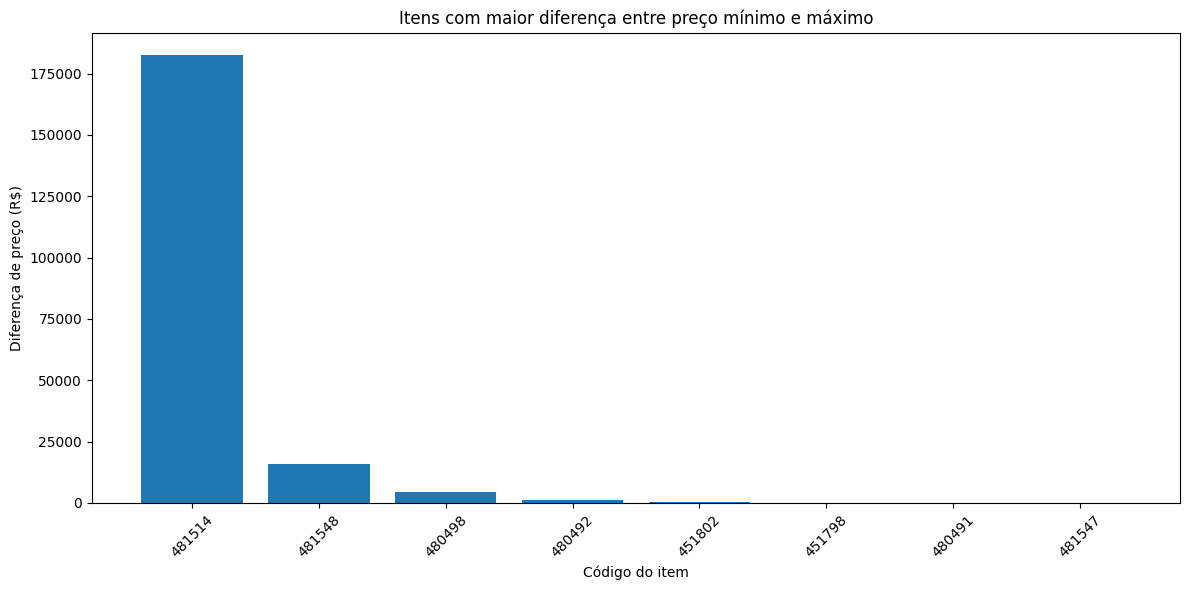

In [ ]:
top_variacoes = comparacao_precos.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_variacoes.index.astype(str),
    top_variacoes["diferenca_preco"]
)

plt.xlabel("Código do item")
plt.ylabel("Diferença de preço (R$)")
plt.title("Itens com maior diferença entre preço mínimo e máximo")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()